# Atividade 2 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 10 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural multilayer perceptron para distinguir atributos que definem a renda média de uma pessoa adulta a partir do _UCI Adult Income Dataset_

## Material de Referência para Estudo

- https://docs.pytorch.org/docs/stable/nn.html
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://sebastianraschka.com/teaching/pytorch-1h/#7-a-typical-training-loop



## Trio

- Adriana Raffaella
- Davi Aguiar
- Henrique Furtado

In [207]:
# Bibliotecas
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from prettytable import PrettyTable
from sklearn.model_selection import train_test_split

# Abertura e Análise Exploratória do Dataset

- A tarefa a ser considerada é uma tarefa de classificação binária, cujo objetivo é determinar se a renda média de uma pessoa adulta excedará os US $50,000 por ano.
- O dataset em questão pode ser obtido aqui: https://archive.ics.uci.edu/dataset/2/adult
- Faça uma pré-seleção dos exemplos, conforme sugerido pelos autores: (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))
- Exclua todas as linhas com dados faltantes
- Quantos exemplos viáveis há no dataset?
- Preparação de atributos: todos os atributos categóricos devem ser codificados com One-Hot Encoding
- O dataset é balanceado?

In [208]:
# fetch dataset 
adult = fetch_ucirepo(id=2)

In [209]:
df_adult_original = adult.data.original
df_adult_original['income'] = df_adult_original['income'].str.replace(".", "", regex=False)
df_adult = df_adult_original.replace("?", pd.NA).dropna().copy()

In [210]:
# fnlwgt corresponde ao número de pessoas que aquela linha representa. Normalmente se utiliza uma normalização desse dado.
df_adult['afnlwgt'] = df_adult['fnlwgt'] / df_adult['fnlwgt'].mean()

#  AGI é a renda brunta
df_adult['agi'] = df_adult['capital-gain'] - df_adult['capital-loss']

df_adult = df_adult.drop(labels=['fnlwgt', 'capital-gain', 'capital-loss'], axis=1)

df_adult_clean = df_adult[(df_adult['age'] > 16) & (df_adult['afnlwgt'] > 1) & (df_adult['hours-per-week'] > 0) & (df_adult['agi'] > 100)]

print(f"Dataset antes de data engineerig: {df_adult_original.shape[0]}")
print(f"Dataset depois de data engineerig: {df_adult.shape[0]}")

df_adult = pd.get_dummies(df_adult_clean, dtype=int)

Dataset antes de data engineerig: 48842
Dataset depois de data engineerig: 45222


In [211]:
df_adult.head()

,age,education-num,hours-per-week,afnlwgt,agi,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,income_<=50K,income_>50K
84,44,9,40,1.810902,14344,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
101,44,13,60,1.045049,15024,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
105,32,9,40,1.674232,7688,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
113,28,10,25,1.991565,4064,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
208,58,9,35,1.109776,15024,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1


In [212]:
df_adult.tail()

,age,education-num,hours-per-week,afnlwgt,agi,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,income_<=50K,income_>50K
48703,39,14,40,1.389782,3137,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
48745,59,13,40,1.870759,3103,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
48757,33,10,40,1.065451,2829,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
48770,29,9,45,1.519116,4386,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
48822,40,15,55,1.065530,15024,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


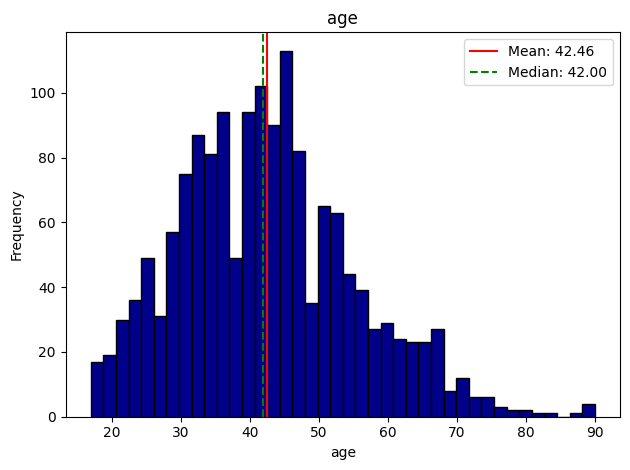

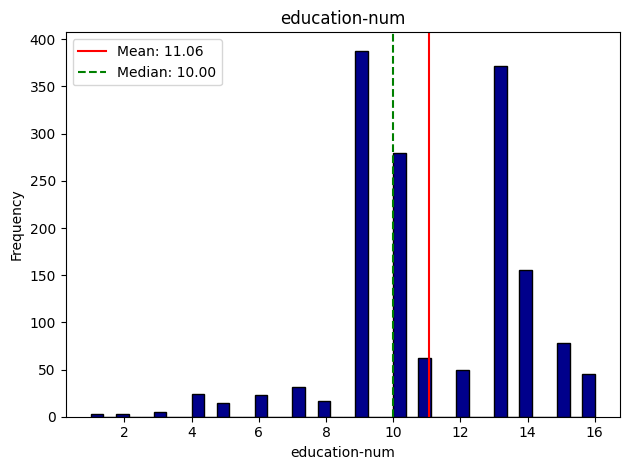

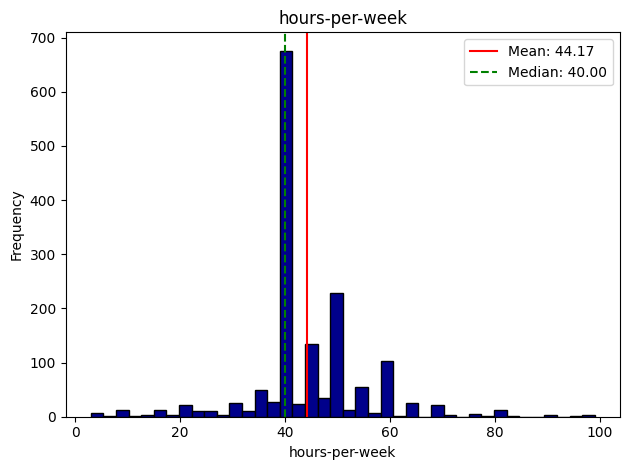

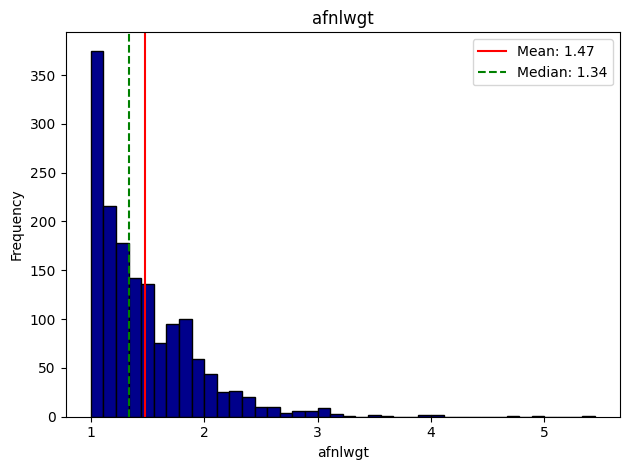

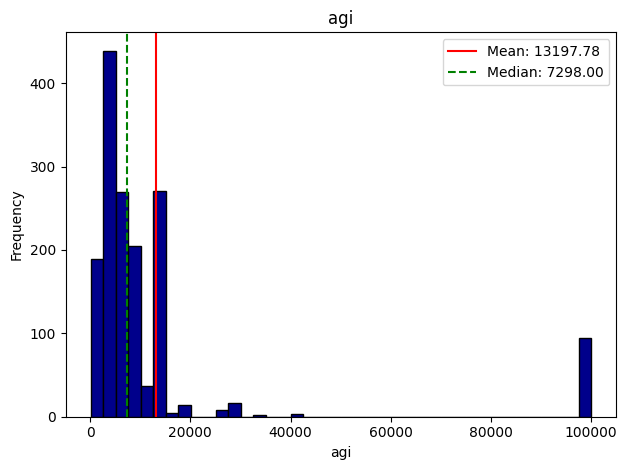

In [213]:
# Atributos númericos

num_features = ['age', 'education-num', 'hours-per-week', 'afnlwgt', 'agi']

for nf in num_features:
    mean = df_adult[nf].mean()
    median = df_adult[nf].median()

    plt.axvline(mean, color='red', linestyle="-", label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='green', linestyle='--', label=f'Median: {median:.2f}')
    plt.hist(df_adult[nf], bins=40, edgecolor='black', color='darkblue')
    plt.title(nf)
    plt.xlabel(nf)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

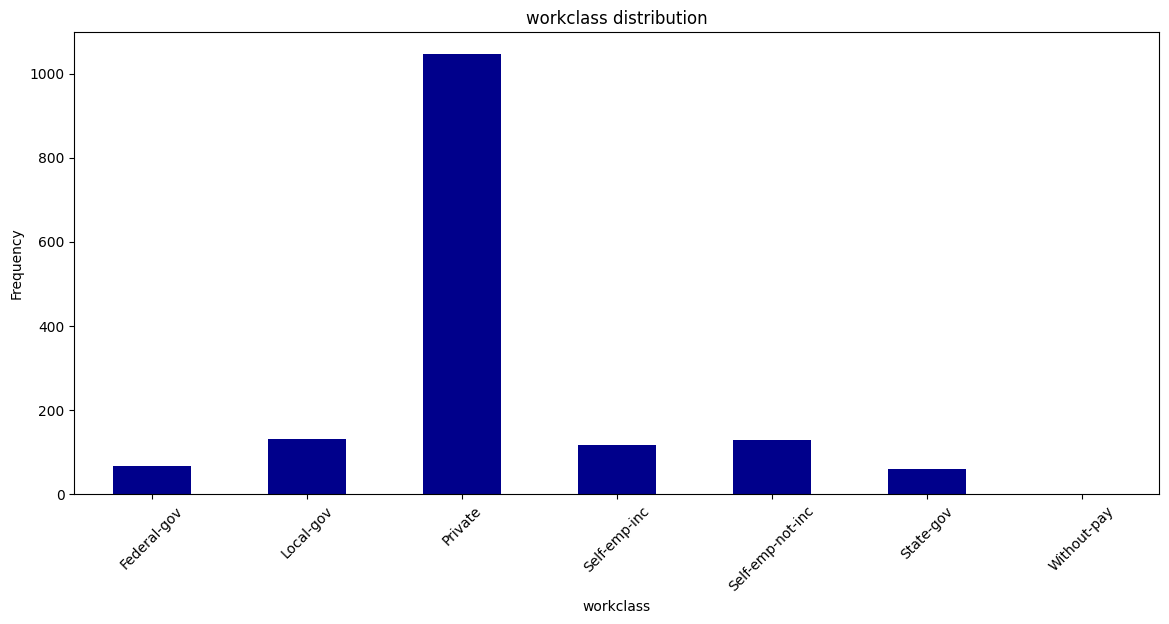

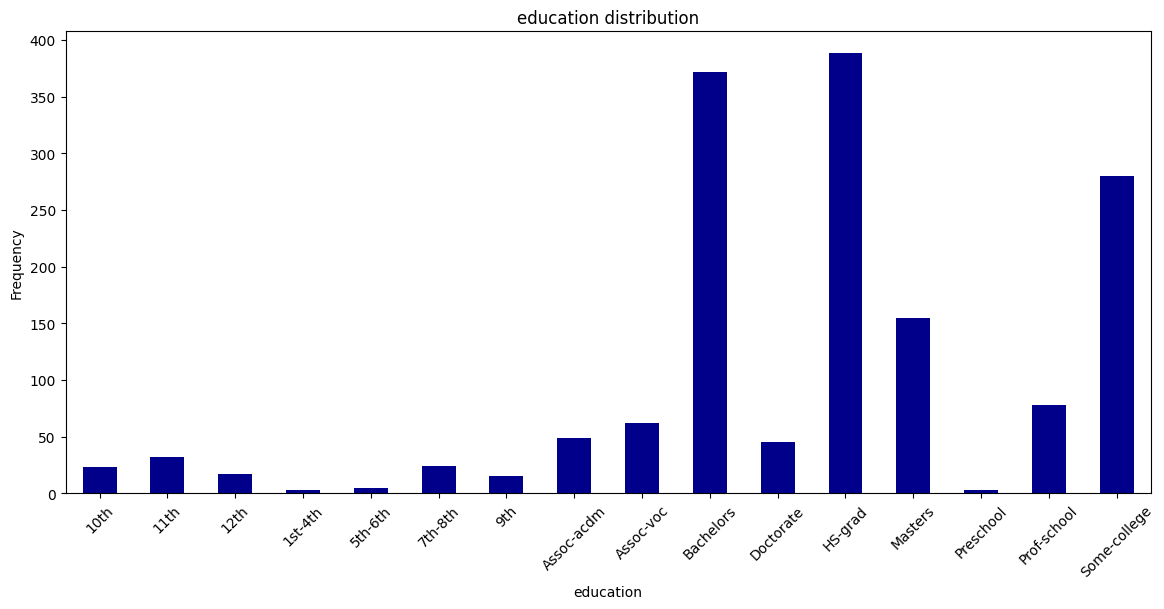

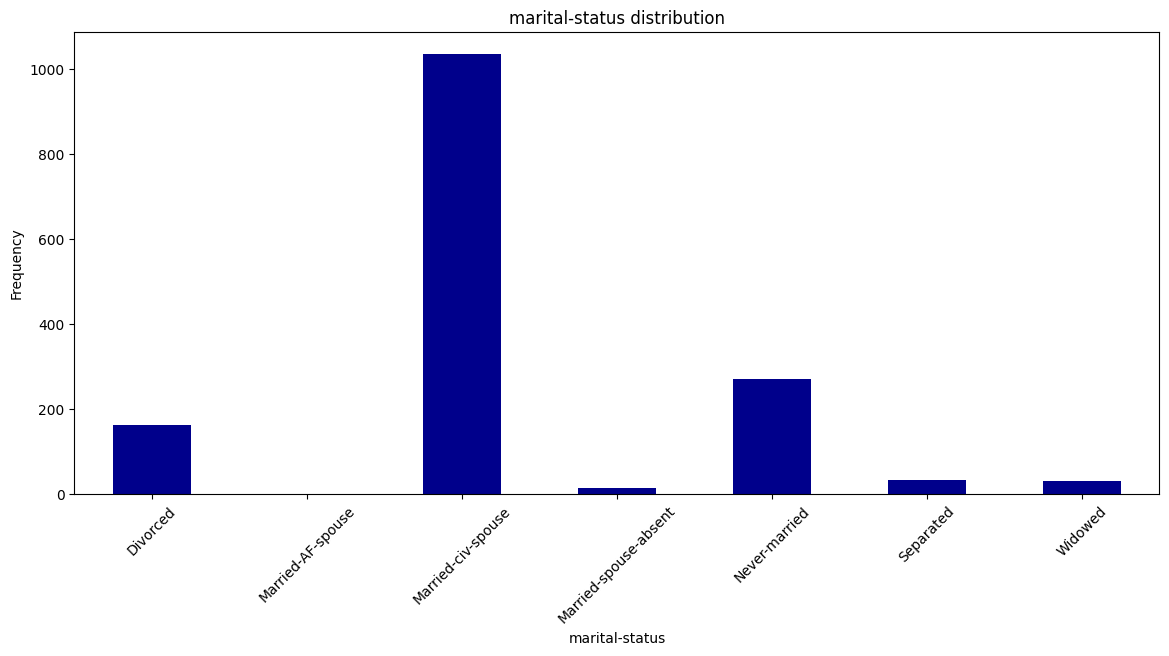

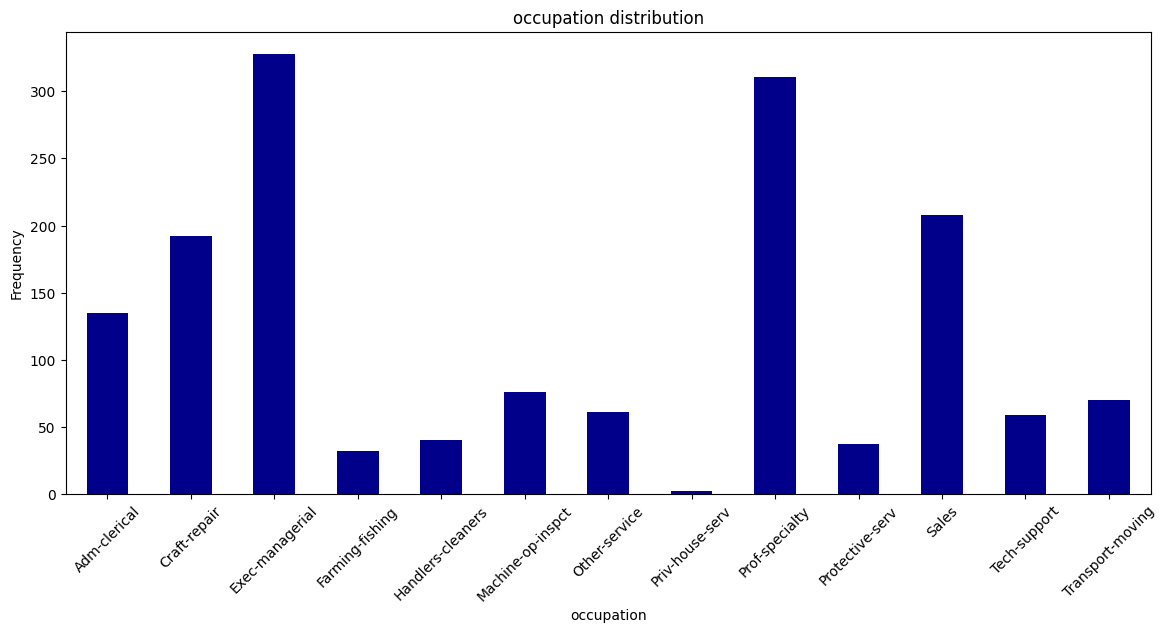

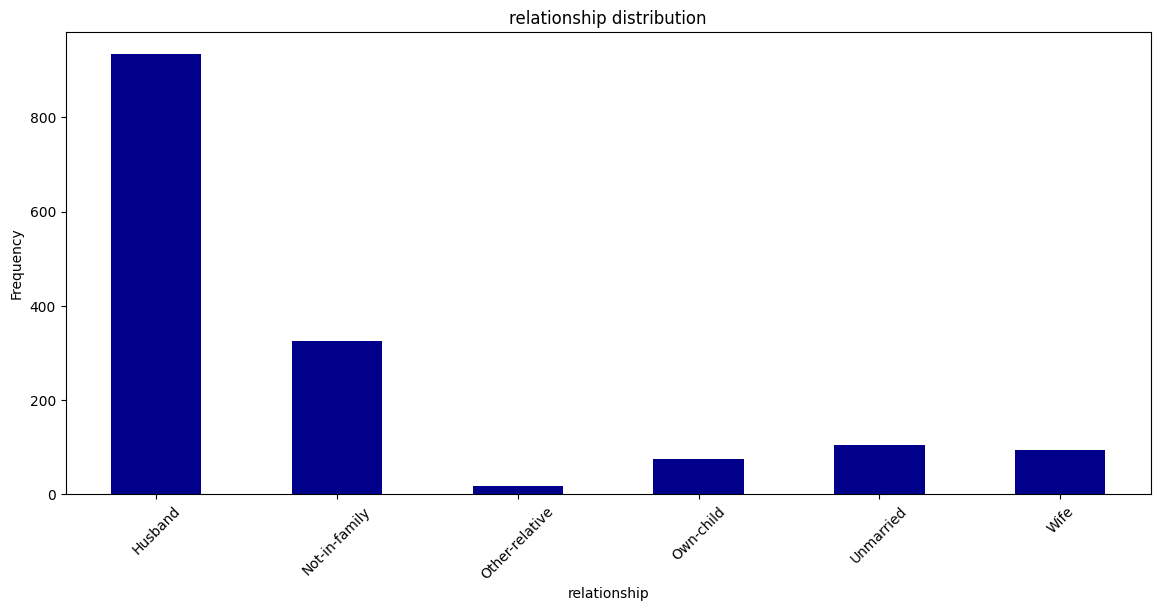

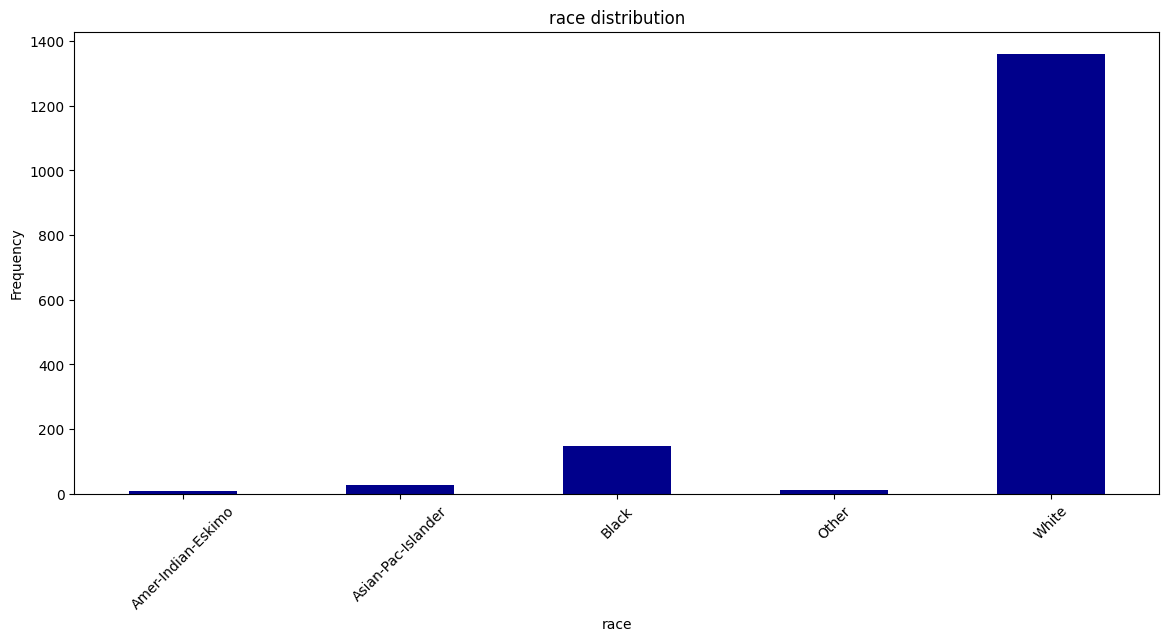

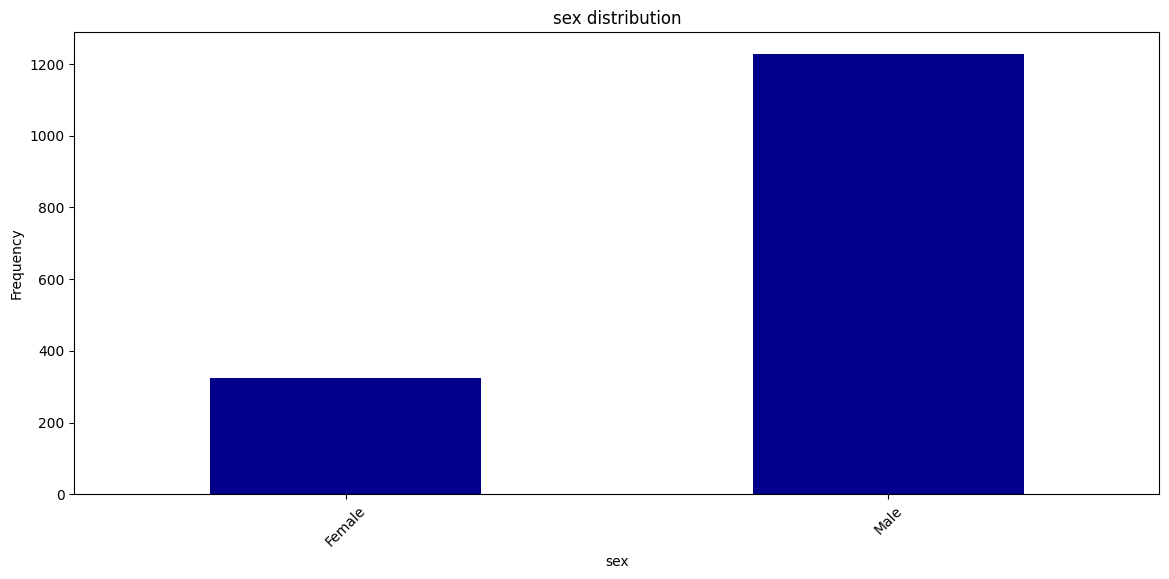

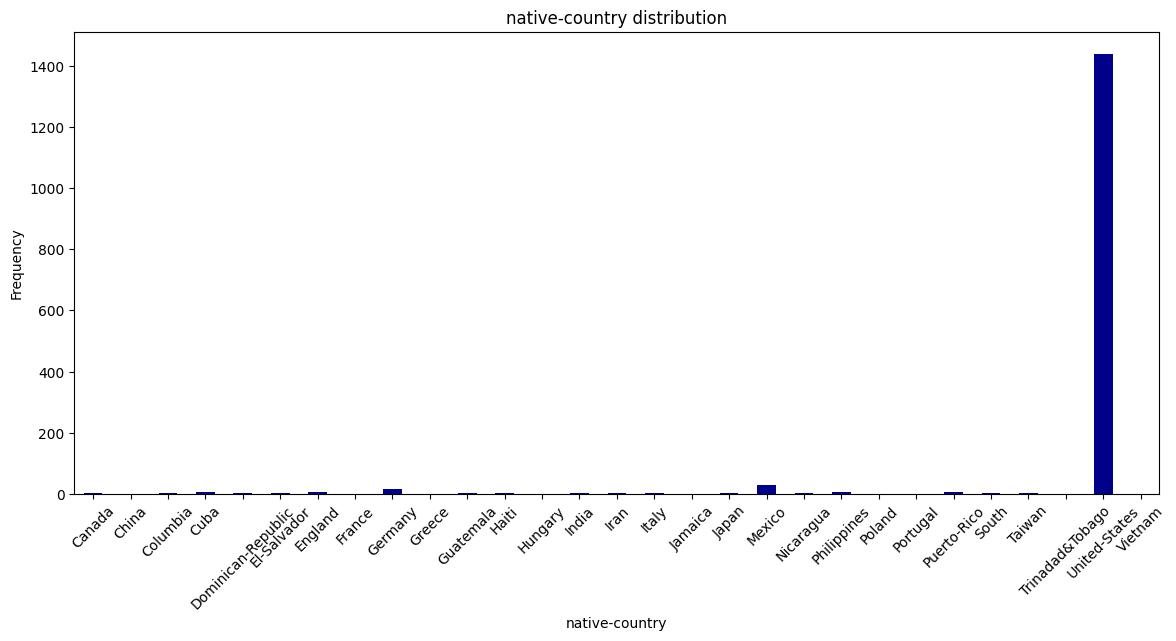

In [214]:
# Atributos categóricos

cat_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for cf in cat_features:
    cols = df_adult.filter(regex=f"^{cf}_")
    df_adult_clean[cf].value_counts().sort_index().plot(kind='bar', color='darkblue', figsize=(14,6))
    plt.title(f'{cf} distribution')
    plt.xlabel(cf)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

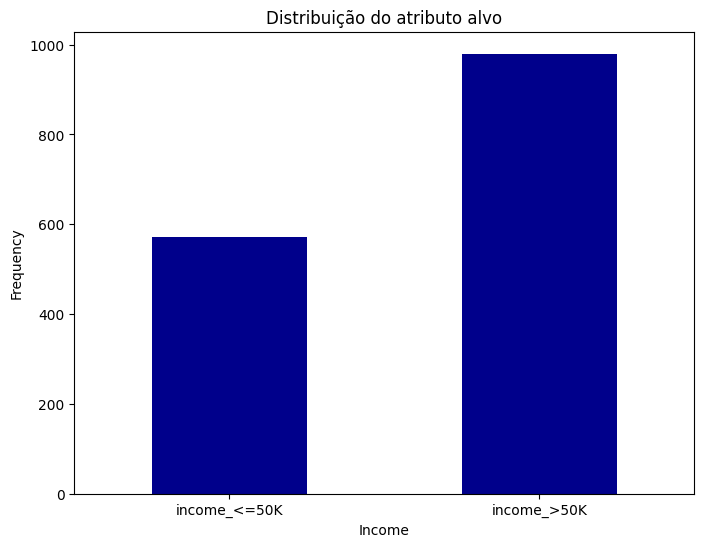

In [215]:
df_adult[['income_<=50K', 'income_>50K']].sum().plot(kind='bar', color='darkblue', figsize=(8,6))
plt.title('Distribuição do atributo alvo')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

##### Dataset desbalanceado! Praticamente todas as classes apresentam um desbalanceamento relevante para o treinamento, considerar esse desbalanceamento ao avaliar modelo.

## Preparação dos exemplos para treino e teste

- Separe os atributos preditores do atributo-alvo
- Faça uma partição do tipo holdout 70/30 de forma aleatória, use seed = 42
- Codifique os exemplos em tensores pytorch

In [216]:
X = df_adult.drop(labels=['income_<=50K', 'income_>50K'], axis=1)
y = df_adult[['income_<=50K', 'income_>50K']]

In [217]:
def holdout(X, y, state):
    return train_test_split(X, y, test_size=0.3, random_state=state)

X_train, X_test, y_train, y_test = holdout(X, y, 42)

In [218]:
X_train_tensor = torch.tensor(X_train.to_numpy())
X_test_tensor = torch.tensor(X_test.to_numpy())
y_train_tensor = torch.tensor(y_train.to_numpy())
y_test_tensor = torch.tensor(y_test.to_numpy())

## Rede MLP de Camada Única

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da MLP de Camada Única

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da rede perante essa tarefa?

## Rede MLP com duas camadas ocultas

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta 1: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada oculta 2: 50 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da MLP com Duas Camadas Ocultas

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da nova rede perante essa tarefa? Houve melhora?

## Sua rede MLP

- Proponha uma rede neural multilayer perceptron no Pytorch com uma ou duas camadas ocultas e número de neurônios conforme sua livre escolha, levando em conta razoabilidade,  tempo de execução no hardware disponível e prazo de entrega da atividade
- Hiperparâmetros:
   - Modifique-os como desejar
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da sua rede MLP

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste

## Análise Comparativa Final

Construa uma tabela (pacote prettytable) com as métricas de desempenho das três redes propostas na partição de testes e justifique, com base em argumentos de performance, eficiência e aderência ao problema, qual delas possivelmente obteve melhor desempenho na tarefa.